# Visualising inputs (strain + witness)

In [1]:
from pathlib import Path
import h5py
import numpy as np
import matplotlib.pyplot as plt
from gwpy.timeseries import TimeSeries

In [17]:
OUT_DIR = Path("../dataset/out")
SAMPLE_RATE = 4096 
EXAMPLE_INDEX = 2

CLASSES = ["background", "signal", "glitch", "signal_glitch"]
CHANNELS = ["strain", "witness"]
COLORS = {"strain": "#1f77b4", "witness": "#d62728"}

In [18]:
def load_example(cls, index=EXAMPLE_INDEX, out_dir=OUT_DIR, sample_rate=SAMPLE_RATE):
    path = Path(out_dir) / f"{cls}.h5"
    
    with h5py.File(path, "r") as f:
        sample = f["data"][index]  # (2, T)
        chan_names = [
            c.decode() if isinstance(c, (bytes, bytearray)) else str(c)
            for c in f.attrs["channels"]
        ]
    return {
        name: TimeSeries(
            sample[i].astype(float),
            sample_rate=sample_rate,
            name=f"{cls} — {name}",
        )
        for i, name in enumerate(chan_names)
    }


examples = {cls: load_example(cls) for cls in CLASSES}
print({cls: {ch: ts.shape for ch, ts in chans.items()} for cls, chans in examples.items()})

{'background': {'strain': (4096,), 'witness': (4096,)}, 'signal': {'strain': (4096,), 'witness': (4096,)}, 'glitch': {'strain': (4096,), 'witness': (4096,)}, 'signal_glitch': {'strain': (4096,), 'witness': (4096,)}}


In [19]:
def load_snr(cls, index=EXAMPLE_INDEX, out_dir=OUT_DIR):
    """Matched-filter SNR label(s) for an example, per channel.

    Signals are injected into the strain only (``snr``); glitches carry a
    separate ``strain_snr`` and ``witness_snr``; background has no injection.
    These are the exact achieved SNRs stored at generation time.
    """
    with h5py.File(Path(out_dir) / f"{cls}.h5", "r") as f:
        if "snr" in f:
            return {"strain": float(f["snr"][index])}
        if "strain_snr" in f:
            return {"strain": float(f["strain_snr"][index]),
                    "witness": float(f["witness_snr"][index])}
        return {}


SNRS = {cls: load_snr(cls) for cls in CLASSES}
print(SNRS)

{'background': {}, 'signal': {'strain': 13.8533296585083}, 'glitch': {'strain': 21.98590660095215, 'witness': 39.13799285888672}, 'signal_glitch': {'strain': 13.98819637298584}}


## 1. Time domain

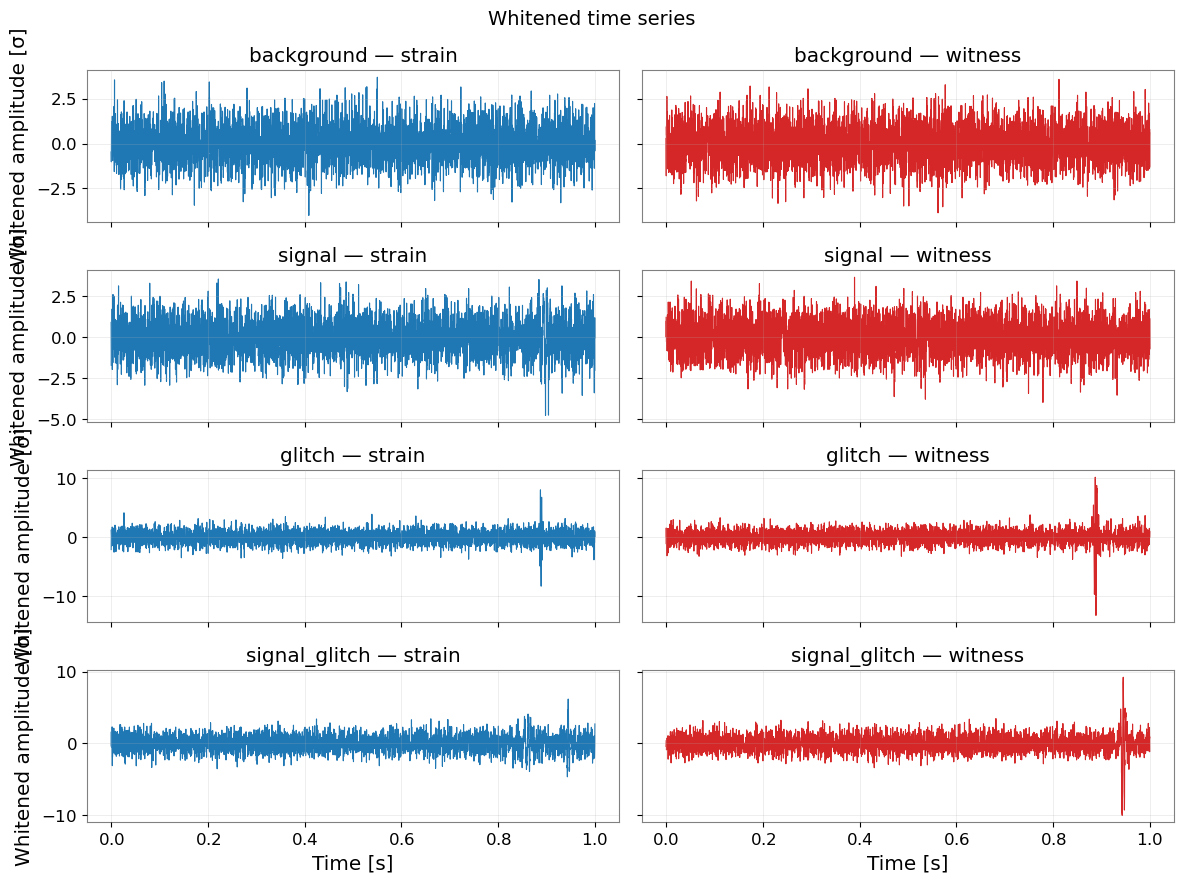

In [20]:
fig, axes = plt.subplots(
    len(CLASSES), len(CHANNELS), figsize=(12, 9), sharex=True, sharey="row"
)

for r, cls in enumerate(CLASSES):
    for c, ch in enumerate(CHANNELS):
        ts = examples[cls][ch]
        ax = axes[r, c]
        ax.plot(ts.times.value, ts.value, lw=0.8, color=COLORS[ch])
        ax.set_title(f"{cls} — {ch}")
        ax.grid(True, alpha=0.3)
        if r == len(CLASSES) - 1:
            ax.set_xlabel("Time [s]")
        if c == 0:
            ax.set_ylabel("Whitened amplitude [σ]")

fig.suptitle("Whitened time series", fontsize=14)
fig.tight_layout()
plt.show()

## 2. Q transform

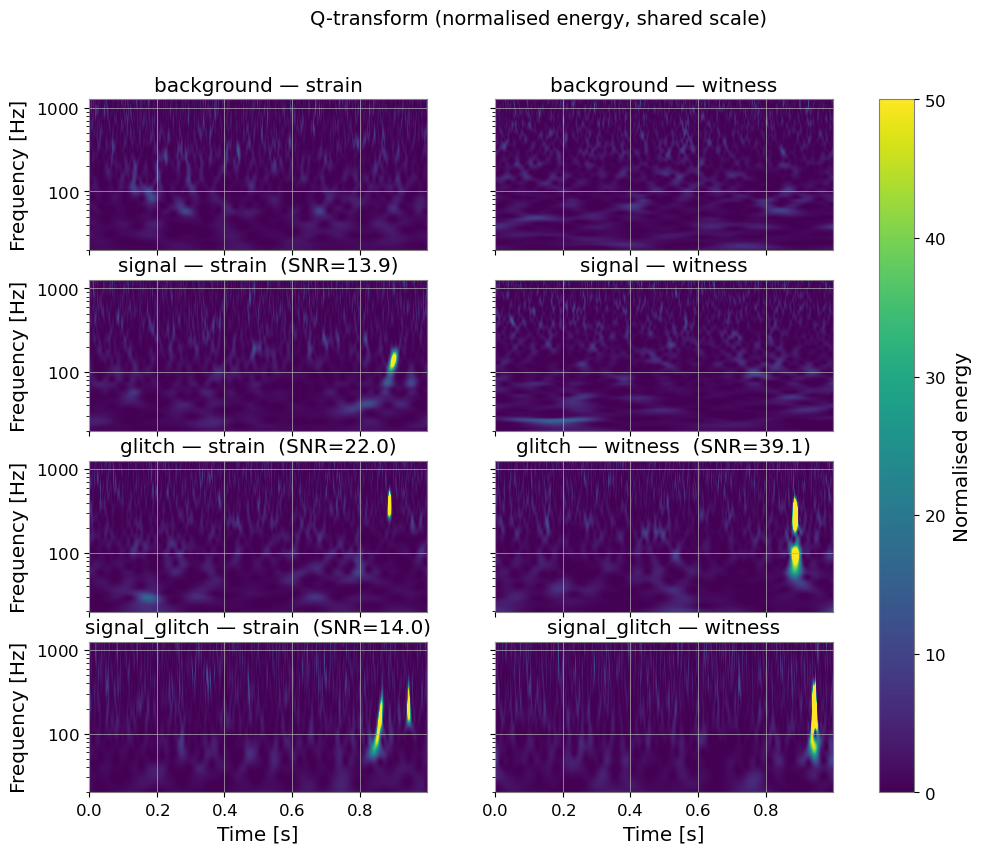

In [21]:
from matplotlib.colors import Normalize

# Compute every Q-transform first so all panels can share one colour scale. A
# Q-scan shows peak *per-tile* energy, so panels are only comparable on a common
# vmin/vmax -- otherwise each panel autoscales and the single colorbar is
# misleading.
qgrams = {}
for cls in CLASSES:
    for ch in CHANNELS:
        qgrams[(cls, ch)] = examples[cls][ch].q_transform(
            whiten=False,
            frange=(20, SAMPLE_RATE / 2),
            qrange=(4, 20),
            logf=True,
        )

norm = Normalize(vmin=0, vmax=50)

fig, axes = plt.subplots(
    len(CLASSES), len(CHANNELS), figsize=(12, 9), sharex=True, sharey=True
)

for r, cls in enumerate(CLASSES):
    for c, ch in enumerate(CHANNELS):
        qgram = qgrams[(cls, ch)]
        ax = axes[r, c]
        mesh = ax.pcolormesh(
            qgram.times.value - qgram.times.value[0],
            qgram.frequencies.value,
            qgram.value.T,
            shading="auto",
            cmap="viridis",
            norm=norm,
        )
        ax.set_yscale("log")
        # Annotate with the true matched-filter SNR so brightness is not mistaken
        # for loudness (see the note below).
        snr = SNRS.get(cls, {}).get(ch)
        title = f"{cls} — {ch}" + (f"  (SNR={snr:.1f})" if snr is not None else "")
        ax.set_title(title)
        if r == len(CLASSES) - 1:
            ax.set_xlabel("Time [s]")
        if c == 0:
            ax.set_ylabel("Frequency [Hz]")

fig.suptitle("Q-transform (normalised energy, shared scale)", fontsize=14)
fig.colorbar(mesh, ax=axes, label="Normalised energy")
plt.show()